# Fitting and comparing TabICL for claims frequency

This notebook follows the data preparation, train/test split, model comparison, and calibration workflow, using the local `freMTPL2freq.csv` file.

The comparison includes an exposure-based null model, a Poisson GLM, four tree ensembles (random forest, extra trees, CatBoost, and XGBoost), and TabICL. CatBoost and XGBoost are each fitted on the full training partition and again on the same claim-count-stratified subset as TabICL at each `TABICL_CONTEXT_SIZES` value. Each size is sampled independently by stratifying `ClaimNb` into 0, 1, and 2+; the subsets are not nested. TabICL additionally receives log exposure as an input feature, and every model predicts on the same full holdout.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from IPython.display import display
from skrub import TableVectorizer
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import PoissonRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from tabicl import TabICLRegressor
from xgboost import XGBRegressor

SEED = 12345

c:\Users\alygu\anaconda3\envs\env_tabicl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the motor-claims data

The feature columns match the French motor third-party liability example in the CANN notebook. `ClaimNb` is the observed claim count and `Exposure` is the policy time at risk. All valid rows are loaded. The classical frequency models fit `ClaimNb / Exposure` with `Exposure` as `sample_weight`; TabICL uses an exposure-weighted context sample because its documented `fit(X, y)` API has no sample-weight argument.

In [2]:
feature_columns = [
    'Area',
    'VehBrand',
    'VehGas',
    'Region',
    'BonusMalus',
    'VehPower',
    'VehAge',
    'DrivAge',
    'Density',
]
required_columns = feature_columns + ['ClaimNb', 'Exposure']

candidate_paths = [
    Path('freMTPL2freq.csv'),
    Path('modelling') / 'freMTPL2freq.csv',
]
data_path = next((path for path in candidate_paths if path.is_file()), None)
if data_path is None:
    raise FileNotFoundError(
        'Expected freMTPL2freq.csv beside this notebook or under ./modelling.'
    )

data = pd.read_csv(data_path)
missing_columns = sorted(set(required_columns).difference(data.columns))
if missing_columns:
    raise ValueError(f'Missing required columns in {data_path}: {missing_columns}')
data = data[required_columns].copy()
if data.isna().any().any():
    columns_with_missing = data.columns[data.isna().any()].tolist()
    raise ValueError(f'Missing values in required columns: {columns_with_missing}')
if not data['Exposure'].gt(0).all():
    raise ValueError('Exposure must be strictly positive for frequency modelling.')
if not data['ClaimNb'].ge(0).all():
    raise ValueError('ClaimNb must be non-negative.')

rows_loaded = len(data)
data = data.reset_index(drop=True)

print(f'Loaded {rows_loaded:,} rows from {data_path}.')
print(f'Using the full dataset of {len(data):,} policies for modelling.')
print(f'Claims in dataset: {int(data.ClaimNb.sum()):,}')
print(
    f'Observed frequency: '
    f'{data.ClaimNb.sum() / data.Exposure.sum():.3f} claims per exposure unit'
)
display(data.head())

Loaded 678,013 rows from freMTPL2freq.csv.
Using the full dataset of 678,013 policies for modelling.
Claims in dataset: 36,102
Observed frequency: 0.101 claims per exposure unit


,Area,VehBrand,VehGas,Region,BonusMalus,VehPower,VehAge,DrivAge,Density,ClaimNb,Exposure
0,D,B12,Regular,R82,50,5,0,55,1217,1,0.10
1,D,B12,Regular,R82,50,5,0,55,1217,1,0.77
2,B,B12,Diesel,R22,50,6,2,52,54,1,0.75
3,B,B12,Diesel,R72,50,7,0,46,76,1,0.09
4,B,B12,Diesel,R72,50,7,0,46,76,1,0.84


## Split the data

Keep the holdout set out of fitting. Exposure is retained separately for weighting, the portfolio baseline, and frequency calibration.

In [3]:
X = data[feature_columns]
y_claims = data['ClaimNb']
exposure = data['Exposure']
y_frequency = y_claims / exposure

(
    X_train,
    X_test,
    y_train_frequency,
    y_test_frequency,
    y_train_claims,
    y_test_claims,
    exposure_train,
    exposure_test,
) = train_test_split(
    X,
    y_frequency,
    y_claims,
    exposure,
    test_size=0.25,
    random_state=SEED,
)
print(f'Train rows: {len(X_train):,}; test rows: {len(X_test):,}')

Train rows: 508,509; test rows: 169,504


## Define the models

`TabICLRegressor` uses the documented `fit` / `predict` interface, with in-context predictions produced at `predict` time. The Poisson GLM, random forest, extra trees, and XGBoost use `TableVectorizer` for mixed categorical and numeric columns; CatBoost receives the raw categorical columns. Conventional models are fitted on the full training partition with exposure sample weights. CatBoost and XGBoost are also refitted on each context subset, retaining exposure sample weights. TabICL does not accept `sample_weight`; its contexts are selected with `train_test_split(..., stratify=...)` using `ClaimNb` bins (0, 1, 2+), without exposure-proportional sampling. Contexts are sampled independently by size rather than nested. Log exposure is added as an input feature for TabICL only. Each context predicts the same full test partition. The fit cell checks PyTorch CUDA availability, explicitly selects CUDA when available, and prints TabICL's resolved device. If PyTorch cannot see CUDA, install a CUDA-enabled PyTorch build for this notebook kernel; see the [PyTorch install selector](https://pytorch.org/get-started/locally/). KV caching is enabled for repeated test batches and uses additional memory.

In [4]:
categorical_columns = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

baseline_models = {
    'Poisson GLM': make_pipeline(
        TableVectorizer(), 
        StandardScaler(with_mean=False),
        PoissonRegressor(alpha=0.05,max_iter=2_000, tol=1e-7)
    ),
    'Random forest': make_pipeline(
        TableVectorizer(),
        StandardScaler(with_mean=False),
        RandomForestRegressor(
            criterion='poisson',
            n_estimators=200,
            n_jobs=-1,
            random_state=SEED,
        ),
    ),
    'CatBoost': make_pipeline(
        CatBoostRegressor(
            loss_function='Poisson',
            iterations=500,
            depth=8,
            learning_rate=0.05,
            cat_features=categorical_columns,
            random_seed=SEED,
            thread_count=-1,
            verbose=False,
            allow_writing_files=False,
        ),
    ),
    'XGBoost': make_pipeline(
        TableVectorizer(),
        XGBRegressor(
            objective='count:poisson',
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method='hist',
            n_jobs=-1,
            random_state=SEED,
            verbosity=0,
        ),
    ),
}

TABICL_CONTEXT_SIZES = (1_000, 5_000)#, 10_000, 20_000, 30_000)
TABICL_TEST_BATCH_SIZE = 5_000

## Fit and predict

The null model predicts the training portfolio's claims per exposure unit. The GLM and other full-data tree models fit claim frequency with exposure weights on all training rows. CatBoost and XGBoost are additionally fitted with exposure weights on each independently stratified context subset used by TabICL. Contexts are stratified by `ClaimNb` bins (0, 1, 2+) and are not nested. TabICL also receives log exposure as an input feature. Predictions use the full test partition; TabICL predictions are batched to limit memory.

In [5]:
import torch
from sklearn.base import clone


if torch.cuda.is_available():
    TABICL_DEVICE = 'cuda'
    print(f'CUDA available to PyTorch: {torch.cuda.get_device_name(0)}')
else:
    TABICL_DEVICE = None
    print(
        f'CUDA unavailable to PyTorch (version={torch.__version__}, '
        f'CUDA build={torch.version.cuda}); TabICL will auto-select a device.'
    )

elapsed_fit_seconds = {}
elapsed_predict_seconds = {}

start_time = perf_counter()
training_frequency = y_train_claims.sum() / exposure_train.sum()
elapsed_fit_seconds['Exposure-weighted null'] = perf_counter() - start_time
predict_start = perf_counter()
predicted_claims = {
    'Exposure-weighted null': training_frequency * exposure_test.to_numpy()
}
elapsed_predict_seconds['Exposure-weighted null'] = perf_counter() - predict_start

skip_models = ['Poisson GLM','Random forest','Extra trees','TabICL (context=1,000)','TabICL (context=10,000)','TabICL (context=20,000)','TabICL (context=25,000)']
skip_models = []

for model_name, model in baseline_models.items():
    if model_name in skip_models:
        print(f'Skipping {model_name}...')
        continue
    final_step_name = model.steps[-1][0]
    print(f'Fitting {model_name}...')
    start_time = perf_counter()
    model.fit(
        X_train,
        y_train_frequency,
        **{f'{final_step_name}__sample_weight': exposure_train},
    )
    elapsed_fit_seconds[model_name] = perf_counter() - start_time
    predict_start = perf_counter()
    model_frequency_prediction = np.asarray(
        model.predict(X_test), dtype=float
    ).reshape(-1)
    elapsed_predict_seconds[model_name] = perf_counter() - predict_start

    if len(model_frequency_prediction) != len(X_test):
        raise RuntimeError(f'{model_name} did not predict every test row.')
    predicted_claims[model_name] = (
        np.maximum(model_frequency_prediction, 1e-8)
        * exposure_test.to_numpy()
    )

X_train_tabicl = X_train.assign(
    LogExposure=np.log(exposure_train.to_numpy(dtype=float))
)
X_test_tabicl = X_test.assign(
    LogExposure=np.log(1)
)

if max(TABICL_CONTEXT_SIZES) > len(X_train):
    raise ValueError('Training partition is smaller than the largest TabICL context.')

context_strata = np.minimum(y_train_claims.to_numpy(dtype=int), 2)
train_indices = np.arange(len(X_train))
context_indices_by_size = {}
for context_size in TABICL_CONTEXT_SIZES:
    context_indices, _ = train_test_split(
        train_indices,
        train_size=context_size,
        random_state=SEED,
        stratify=context_strata,
    )
    context_indices_by_size[context_size] = context_indices

for context_size in TABICL_CONTEXT_SIZES:
    context_indices = context_indices_by_size[context_size]
    context_X_train = X_train.iloc[context_indices]
    context_y_train_frequency = y_train_frequency.iloc[context_indices]
    context_exposure_train = exposure_train.iloc[context_indices]

    for baseline_model_name in ('CatBoost', 'XGBoost'):
        context_model_name = (
            f'{baseline_model_name} (context={context_size:,})'
        )
        if context_model_name in skip_models:
            print(f'Skipping {context_model_name}...')
            continue
        baseline_model = baseline_models[baseline_model_name]
        if baseline_model_name == 'CatBoost':
            context_model = make_pipeline(
                CatBoostRegressor(**baseline_model.steps[-1][1].get_params())
            )
        else:
            context_model = clone(baseline_model)
        context_step_name = context_model.steps[-1][0]
        print(f'Fitting {context_model_name}...')
        start_time = perf_counter()
        context_model.fit(
            context_X_train,
            context_y_train_frequency,
            **{f'{context_step_name}__sample_weight': context_exposure_train},
        )
        elapsed_fit_seconds[context_model_name] = perf_counter() - start_time
        predict_start = perf_counter()
        context_frequency_prediction = np.asarray(
            context_model.predict(X_test), dtype=float
        ).reshape(-1)
        if len(context_frequency_prediction) != len(X_test):
            raise RuntimeError(f'{context_model_name} did not predict every test row.')
        elapsed_predict_seconds[context_model_name] = (
            perf_counter() - predict_start
        )
        predicted_claims[context_model_name] = (
            np.maximum(context_frequency_prediction, 1e-8)
            * exposure_test.to_numpy()
        )

    model_name = f'TabICL (context={context_size:,})'
    if model_name in skip_models:
        print(f'Skipping {model_name}...')
        continue
    tabicl_model = make_pipeline(
        TabICLRegressor(device=TABICL_DEVICE, kv_cache=True),
    )
    print(f'Fitting {model_name}...')
    if TABICL_DEVICE == 'cuda':
        torch.cuda.synchronize()
    start_time = perf_counter()
    tabicl_model.fit(
        X_train_tabicl.iloc[context_indices],
        y_train_frequency.iloc[context_indices],
    )
    if TABICL_DEVICE == 'cuda':
        torch.cuda.synchronize()
    elapsed_fit_seconds[model_name] = perf_counter() - start_time
    tabicl_estimator = tabicl_model.steps[-1][1]
    print(f'{model_name} resolved device: {tabicl_estimator.device_}')

    if TABICL_DEVICE == 'cuda':
        torch.cuda.synchronize()
    predict_start = perf_counter()
    prediction_batches = []
    for batch_start in range(0, len(X_test), TABICL_TEST_BATCH_SIZE):
        batch_stop = min(batch_start + TABICL_TEST_BATCH_SIZE, len(X_test))
        batch_prediction = np.asarray(
            tabicl_model.predict(
                X_test_tabicl.iloc[batch_start:batch_stop]
            ), dtype=float
        ).reshape(-1)
        prediction_batches.append(batch_prediction)

    model_frequency_prediction = np.concatenate(prediction_batches)
    if len(model_frequency_prediction) != len(X_test):
        raise RuntimeError(f'{model_name} did not predict every test row.')
    if TABICL_DEVICE == 'cuda':
        torch.cuda.synchronize()
    elapsed_predict_seconds[model_name] = perf_counter() - predict_start
    predicted_claims[model_name] = (
        np.maximum(model_frequency_prediction, 1e-8)
        * exposure_test.to_numpy()
    )

CUDA available to PyTorch: NVIDIA GeForce GTX 1080 Ti
Fitting Poisson GLM...
Fitting Random forest...
Fitting CatBoost...
Fitting XGBoost...
Fitting CatBoost (context=1,000)...
Fitting XGBoost (context=1,000)...
Fitting TabICL (context=1,000)...
TabICL (context=1,000) resolved device: cuda
Fitting CatBoost (context=5,000)...
Fitting XGBoost (context=5,000)...
Fitting TabICL (context=5,000)...
TabICL (context=5,000) resolved device: cuda


## Compare holdout performance

The table reports MSE and MAE on claim counts, plus the sample variance and standard deviation of signed count residuals (`observed - predicted`). Gini is the raw exposure-weighted Lorenz Gini, ranking policies by predicted frequency; higher is better. Fit and predict times are reported separately. TabICL fit time includes checkpoint loading and KV-cache construction; CUDA timings synchronize the GPU.

In [6]:
from sklearn.metrics import mean_absolute_error, mean_poisson_deviance, mean_squared_error

def exposure_weighted_gini(actual_claims, predicted_frequency, exposure):
    actual_claims = np.asarray(actual_claims, dtype=float).reshape(-1)
    predicted_frequency = np.asarray(predicted_frequency, dtype=float).reshape(-1)
    exposure = np.asarray(exposure, dtype=float).reshape(-1)
    if not (len(actual_claims) == len(predicted_frequency) == len(exposure)):
        raise ValueError('Gini inputs must have matching lengths.')
    if len(actual_claims) == 0:
        raise ValueError('Gini requires at least one observation.')
    if not (
        np.isfinite(actual_claims).all()
        and np.isfinite(predicted_frequency).all()
        and np.isfinite(exposure).all()
    ):
        raise ValueError('Gini inputs must be finite.')
    if (actual_claims < 0).any() or (exposure <= 0).any():
        raise ValueError('Claims must be non-negative and exposure positive.')

    total_claims = actual_claims.sum()
    if total_claims <= 0:
        raise ValueError('Gini is undefined when the holdout has no claims.')

    ranked = pd.DataFrame(
        {
            'PredictedFrequency': predicted_frequency,
            'ActualClaims': actual_claims,
            'Exposure': exposure,
        }
    )
    grouped = ranked.groupby('PredictedFrequency', sort=True).agg(
        ActualClaims=('ActualClaims', 'sum'),
        Exposure=('Exposure', 'sum'),
    )
    cumulative_exposure = np.r_[
        0.0, grouped['Exposure'].cumsum().to_numpy() / exposure.sum()
    ]
    cumulative_claims = np.r_[
        0.0, grouped['ActualClaims'].cumsum().to_numpy() / total_claims
    ]
    lorenz_area = np.sum(
        0.5
        * (cumulative_claims[1:] + cumulative_claims[:-1])
        * np.diff(cumulative_exposure)
    )
    return float(1.0 - 2.0 * lorenz_area)


score_rows = []
actual_claims = y_test_claims.to_numpy(dtype=float)
test_exposure = exposure_test.to_numpy(dtype=float)
for model_name, prediction in predicted_claims.items():
    residuals = actual_claims - prediction
    score_rows.append(
        {
            'Model': model_name,
            'Poisson deviance (claims)': mean_poisson_deviance(y_test_claims, prediction),
            'MSE': mean_squared_error(actual_claims, prediction),
            'MAE': mean_absolute_error(y_test_claims, prediction),
            'AvE': actual_claims.sum()/prediction.sum(),
            'Exposure-weighted MAE (frequency)': mean_absolute_error(
                actual_claims,
                prediction,
                sample_weight=test_exposure,
            ),
            'Exposure-weighted Gini': exposure_weighted_gini(
                actual_claims,
                prediction / test_exposure,
                test_exposure,
            ),
            'Fit time (seconds)': elapsed_fit_seconds.get(model_name, np.nan),
            'Predict time (seconds)': elapsed_predict_seconds.get(model_name, np.nan),
        }
    )

comparison = (
    pd.DataFrame(score_rows)
    .sort_values('Poisson deviance (claims)')
    .reset_index(drop=True)
)
comparison

,Model,Poisson deviance (claims),MSE,MAE,AvE,Exposure-weighted MAE (frequency),Exposure-weighted Gini,Fit time (seconds),Predict time (seconds)
0,XGBoost,0.302482,0.055729,0.096230,1.003233,0.124256,0.345163,22.113982,1.725687
1,CatBoost,0.304186,0.055887,0.096396,1.005002,0.124448,0.333999,150.649826,0.358627
2,Poisson GLM,0.321960,0.056703,0.099208,1.007895,0.129749,0.237450,10.437760,1.393220
3,"TabICL (context=5,000)",0.325622,0.056648,0.086545,1.384694,0.112465,0.247049,3.596504,69.264781
4,Exposure-weighted null,0.331201,0.057295,0.099806,1.009285,0.133044,-0.026164,0.001683,0.000444
5,"TabICL (context=1,000)",0.334353,0.060956,0.110281,0.810331,0.146649,0.141456,1.572800,46.390048
6,"CatBoost (context=5,000)",0.345508,0.059611,0.088718,1.273129,0.115375,0.155305,25.645117,0.375199
7,"XGBoost (context=5,000)",0.348830,0.061386,0.088920,1.248023,0.115765,0.181597,0.958750,1.759559
8,Random forest,0.362428,0.370035,0.131239,0.557716,0.171272,0.293212,217.330592,4.144764
9,"CatBoost (context=1,000)",0.459455,0.059220,0.062388,5.099305,0.078019,0.032499,22.580397,0.347370


## Check frequency calibration

For each fitted model, group holdout policies into predicted-frequency deciles and compare predicted with observed claims per unit of exposure. The null model is omitted because its predicted frequency is constant and therefore cannot rank policies.

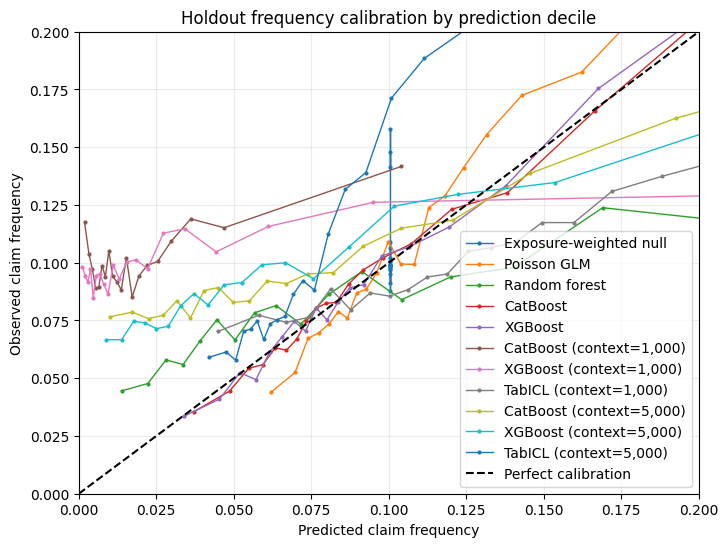

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
for model_name, prediction in predicted_claims.items():
    # if model_name == 'Exposure-weighted null':
    #     continue

    calibration = pd.DataFrame(
        {
            'PredictedClaims': prediction,
            'ObservedClaims': y_test_claims.to_numpy(),
            'Exposure': exposure_test.to_numpy(),
        }
    )
    calibration['PredictedFrequency'] = (
        calibration['PredictedClaims'] / calibration['Exposure']
    )
    calibration['Decile'] = pd.qcut(
        calibration['PredictedFrequency'].rank(method='first'),
        q=20,
        labels=False,
    )
    deciles = calibration.groupby('Decile', observed=True).agg(
        PredictedClaims=('PredictedClaims', 'sum'),
        ObservedClaims=('ObservedClaims', 'sum'),
        Exposure=('Exposure', 'sum'),
    )
    ax.plot(
        deciles['PredictedClaims'] / deciles['Exposure'],
        deciles['ObservedClaims'] / deciles['Exposure'],
        marker='o', 
        #thickeness of line & marker size
        linewidth=1,
        markersize=2,
        label=model_name,
    )

upper = max(ax.get_xlim()[1], ax.get_ylim()[1])
upper = 0.2
ax.plot([0, upper], [0, upper], linestyle='--', color='black', label='Perfect calibration')
ax.set_xlim(0, upper)
ax.set_ylim(0, upper)
ax.set_xlabel('Predicted claim frequency')
ax.set_ylabel('Observed claim frequency')
ax.set_title('Holdout frequency calibration by prediction decile')
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## Interpretation and actuarial caveat

Use the table and calibration plot to compare models on this sampled holdout; do not interpret the scores as evidence that one model will win on the full portfolio. TabICL is pretrained and performs in-context learning at prediction time, rather than fitting neural-network weights on this sample.

All 678,013 rows from the local CSV are loaded. The full-data classical models fit the complete training partition with exposure weights; CatBoost and XGBoost context variants use exposure weights on the same stratified rows as TabICL. Since TabICL's documented `fit(X, y)` API has no `sample_weight`, its independently sampled contexts preserve the row-count distribution of `ClaimNb` bins (0, 1, 2+) but are not exposure-weighted; log exposure is provided as an input feature. For production ratemaking, validate the exposure treatment on a time-based holdout and consider the TabICL context-sampling approach when interpreting comparisons.